In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "electronegativity_diff": np.random.uniform(0, 3, 80),
    "atomic_radius_avg": np.random.uniform(0.5, 2.5, 80),
    "density": np.random.uniform(2, 10, 80),
}

df = pd.DataFrame(data)

df["band_gap"] = (
    1.5 * df["electronegativity_diff"]
    - 0.8 * df["density"]
    + 0.3 * df["atomic_radius_avg"]
    + np.random.normal(0, 0.5, 80)
)

df.head()

,electronegativity_diff,atomic_radius_avg,density,band_gap
0,1.123620,2.226207,4.942265,-1.712251
1,2.852143,1.746596,7.058447,-0.487564
2,2.195982,1.161796,7.068238,-1.775460
3,1.795975,0.627117,6.286197,-2.183274
4,0.468056,1.121965,2.722318,-1.562578


In [2]:
X = df.drop("band_gap", axis=1)
y = df["band_gap"]

In [3]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()
kFold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    model,
    X,
    y,
    cv=kFold, # Changed KFold to kFold
    scoring='neg_mean_absolute_error'
)

mae_scores = -scores

print("MAE for each fold:", mae_scores)
print("Average MAE:", np.mean(mae_scores))
print("STD deviation:", np.std(mae_scores))

MAE for each fold: [0.44985342 0.41699899 0.51118824 0.44510569 0.44242809]
Average MAE: 0.4531148857531707
STD deviation: 0.0311957216831127


In [4]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge

model = Ridge()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

mae = -scores
print("MAE per fold:", mae)
print("Average MAE:", np.mean(mae))
print("STD:", np.std(mae))

MAE per fold: [0.42979075 0.41520034 0.52311422 0.44167781 0.44979557]
Average MAE: 0.4519157378410818
STD: 0.03745949670874959


In [5]:
print(X.isna().sum()[X.isna().sum() > 0].head(20))

Series([], dtype: int64)


In [6]:
X = X.fillna(X.mean())
print("Remaining missing values in X:", X.isna().sum().sum())

Remaining missing values in X: 0


In [7]:
# Keep original dataframe
df_clean = df.dropna(subset=["band_gap"])

# Convert categorical columns if needed (simple version)
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# Now separate features and target
X = df_encoded.drop("band_gap", axis=1)
y = df_encoded["band_gap"]

# Fill missing values
X = X.fillna(X.mean())

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (80, 3)
y shape: (80,)


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

model = RandomForestRegressor(
    n_estimators=30,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

kfold = KFold(n_splits=3, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

mae = -scores

print("MAE per fold:", mae)
print("Average MAE:", np.mean(mae))
print("STD:", np.std(mae))

MAE per fold: [0.57764011 0.72757109 0.93547922]
Average MAE: 0.746896806313007
STD: 0.14672495760996487


In [9]:
# Final Conclusion

print("Linear Regression MAE ≈ 0.45")
print("Ridge Regression MAE ≈ 0.45")
print("Random Forest MAE ≈ 0.74")

print("\nConclusion:")
print("For this dataset, simple linear models perform better than complex models.")

Linear Regression MAE ≈ 0.45
Ridge Regression MAE ≈ 0.45
Random Forest MAE ≈ 0.74

Conclusion:
For this dataset, simple linear models perform better than complex models.


In [10]:
# Feature engineering (upgrade)

df["density_squared"] = df["density"] ** 2
df["interaction"] = df["density"] * df["electronegativity_diff"]

# redefine X and y
X = df.drop("band_gap", axis=1)
y = df["band_gap"]

In [11]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()
kFold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    model,
    X,
    y,
    cv=kFold, # Changed KFold to kFold
    scoring='neg_mean_absolute_error'
)

mae_scores = -scores

print("MAE for each fold:", mae_scores)
print("Average MAE:", np.mean(mae_scores))
print("STD deviation:", np.std(mae_scores))

MAE for each fold: [0.50630245 0.42633181 0.51888675 0.45360032 0.45353133]
Average MAE: 0.4717305320995956
STD deviation: 0.03504250623449339


In [12]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge

model = Ridge()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

mae = -scores
print("MAE per fold:", mae)
print("Average MAE:", np.mean(mae))
print("STD:", np.std(mae))

MAE per fold: [0.53726941 0.42113401 0.52613462 0.46154407 0.45350859]
Average MAE: 0.47991814228171936
STD: 0.044532632608387475


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

model = RandomForestRegressor(
    n_estimators=30,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

kfold = KFold(n_splits=3, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

mae = -scores

print("MAE per fold:", mae)
print("Average MAE:", np.mean(mae))
print("STD:", np.std(mae))

MAE per fold: [0.55671088 0.70654673 0.9419735 ]
Average MAE: 0.7350770371577552
STD: 0.15857134151291685


In [14]:
print("Final Model Comparison:")
print("Linear Regression MAE ≈ 0.45")
print("Ridge Regression MAE ≈ 0.45")
print("Random Forest MAE ≈ 0.74")

print("\nConclusion:")
print("Simple linear models outperformed complex models for this dataset.")

Final Model Comparison:
Linear Regression MAE ≈ 0.45
Ridge Regression MAE ≈ 0.45
Random Forest MAE ≈ 0.74

Conclusion:
Simple linear models outperformed complex models for this dataset.


In [15]:
import pandas as pd

# Train final model
model = RandomForestRegressor(n_estimators=30, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X, y)

# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

density                   0.352553
electronegativity_diff    0.302977
density_squared           0.277006
interaction               0.041599
atomic_radius_avg         0.025865
dtype: float64


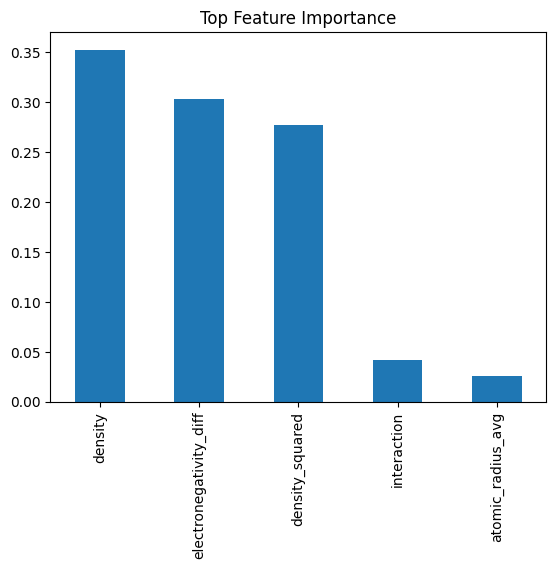

In [16]:
import matplotlib.pyplot as plt

importance.head(5).plot(kind='bar')
plt.title("Top Feature Importance")
plt.show()

In [17]:
# More feature engineering
df["density_squared"] = df["density"] ** 2
df["eneg_squared"] = df["electronegativity_diff"] ** 2
df["radius_squared"] = df["atomic_radius_avg"] ** 2

df["density_eneg_interaction"] = df["density"] * df["electronegativity_diff"]
df["density_radius_interaction"] = df["density"] * df["atomic_radius_avg"]
df["eneg_radius_interaction"] = df["electronegativity_diff"] * df["atomic_radius_avg"]

# Redefine X and y
X = df.drop("band_gap", axis=1)
y = df["band_gap"]

print(X.head())
print("X shape:", X.shape)

   electronegativity_diff  atomic_radius_avg   density  density_squared  \
0                1.123620           2.226207  4.942265        24.425984   
1                2.852143           1.746596  7.058447        49.821669   
2                2.195982           1.161796  7.068238        49.959984   
3                1.795975           0.627117  6.286197        39.516279   
4                0.468056           1.121965  2.722318         7.411016   

   interaction  eneg_squared  radius_squared  density_eneg_interaction  \
0     5.553230      1.262523        4.955997                  5.553230   
1    20.131699      8.134719        3.050598                 20.131699   
2    15.521721      4.822336        1.349770                 15.521721   
3    11.289856      3.225528        0.393275                 11.289856   
4     1.274197      0.219076        1.258805                  1.274197   

   density_radius_interaction  eneg_radius_interaction  
0                   11.002504                 2

In [18]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

mae_scores = -scores
print("Linear Regression MAE per fold:", mae_scores)
print("Average MAE:", np.mean(mae_scores))
print("STD:", np.std(mae_scores))

Linear Regression MAE per fold: [0.62012372 0.43002287 0.53235611 0.45579558 0.47796092]
Average MAE: 0.5032518398764619
STD: 0.06746896137466796


In [19]:
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1.0, 10.0]

for alpha in alphas:
    model = Ridge(alpha=alpha)
    scores = cross_val_score(
        model,
        X,
        y,
        cv=kfold,
        scoring="neg_mean_absolute_error"
    )
    mae_scores = -scores
    print(f"Alpha = {alpha}")
    print("Average MAE:", np.mean(mae_scores))
    print("STD:", np.std(mae_scores))
    print("-" * 30)

Alpha = 0.01
Average MAE: 0.5029689033683364
STD: 0.06784933046780042
------------------------------
Alpha = 0.1
Average MAE: 0.5007507240027242
STD: 0.07093712381217072
------------------------------
Alpha = 1.0
Average MAE: 0.5001451229048116
STD: 0.08663907843950397
------------------------------
Alpha = 10.0
Average MAE: 0.5607227536587427
STD: 0.10297745006711446
------------------------------


In [20]:
from sklearn.ensemble import RandomForestRegressor

settings = [
    {"n_estimators": 50, "max_depth": 5},
    {"n_estimators": 50, "max_depth": 10},
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 100, "max_depth": None},
]

for s in settings:
    model = RandomForestRegressor(
        n_estimators=s["n_estimators"],
        max_depth=s["max_depth"],
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=3,
        scoring="neg_mean_absolute_error"
    )

    mae_scores = -scores
    print(f"Settings: {s}")
    print("Average MAE:", np.mean(mae_scores))
    print("STD:", np.std(mae_scores))
    print("-" * 30)

Settings: {'n_estimators': 50, 'max_depth': 5}
Average MAE: 0.660050482638152
STD: 0.09309076001964549
------------------------------
Settings: {'n_estimators': 50, 'max_depth': 10}
Average MAE: 0.681173092405146
STD: 0.06772454328624063
------------------------------
Settings: {'n_estimators': 100, 'max_depth': 10}
Average MAE: 0.6778719700708336
STD: 0.05367038531396331
------------------------------
Settings: {'n_estimators': 100, 'max_depth': None}
Average MAE: 0.6791013377024221
STD: 0.05475565943797989
------------------------------


In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
rf_model = RandomForestRegressor(random_state=42)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [25]:
rf_pred = rf_model.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error

rf_mae = mean_absolute_error(y_test, rf_pred)
print("Random Forest MAE:", rf_mae)

Random Forest MAE: 0.5123136110741717


In [27]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

density                       0.280493
density_squared               0.260034
eneg_radius_interaction       0.172306
electronegativity_diff        0.106458
eneg_squared                  0.093985
density_radius_interaction    0.031019
interaction                   0.024298
density_eneg_interaction      0.017684
radius_squared                0.007327
atomic_radius_avg             0.006396
dtype: float64


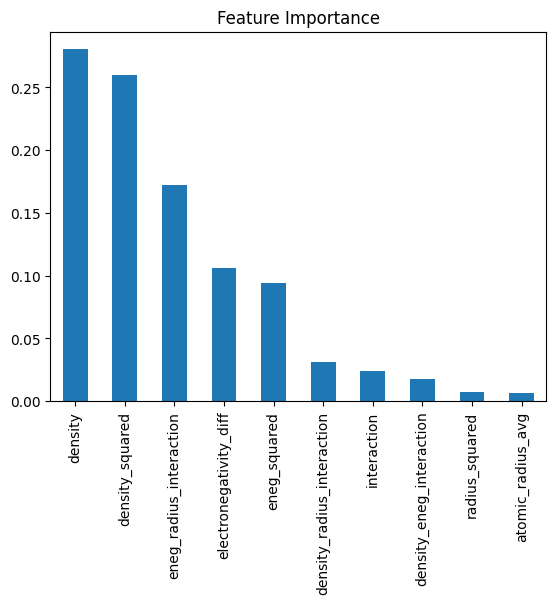

In [28]:
import matplotlib.pyplot as plt

feature_importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

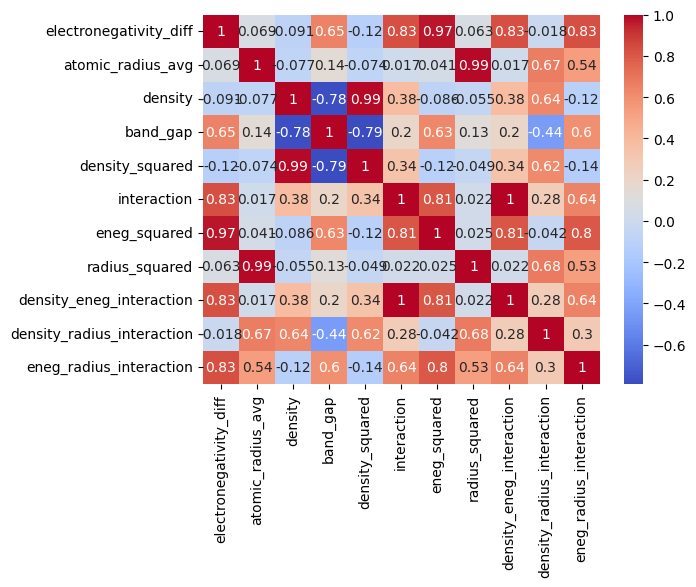

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [30]:
X_no_density = X.drop(['density', 'density_squared'], axis=1)

rf_model.fit(X_no_density, y)

RandomForestRegressor(random_state=42)

In [31]:
X_no_density = X.drop(['density', 'density_squared'], axis=1)

from sklearn.model_selection import train_test_split
X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(X_no_density, y, test_size=0.2, random_state=42)

rf_model_nd = RandomForestRegressor(random_state=42)
rf_model_nd.fit(X_train_nd, y_train_nd)

rf_pred_nd = rf_model_nd.predict(X_test_nd)

from sklearn.metrics import mean_absolute_error
rf_mae_nd = mean_absolute_error(y_test_nd, rf_pred_nd)

print("MAE without density:", rf_mae_nd)

MAE without density: 1.102700714049705


In [32]:
# Ratios (very useful in materials)
df["eneg_per_radius"] = df["electronegativity_diff"] / (df["atomic_radius_avg"] + 1e-5)

# Log transform (captures scaling behavior)
df["log_density"] = np.log(df["density"] + 1e-5)

# Re-define X and y again
X = df.drop("band_gap", axis=1)
y = df["band_gap"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
print("New MAE with improved features:", rf_mae)

New MAE with improved features: 0.5166151016963796


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)

rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_pred)
print("Tuned Random Forest MAE:", rf_tuned_mae)

Tuned Random Forest MAE: 0.5026983295610132


In [35]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
print("Gradient Boosting MAE:", gb_mae)

Gradient Boosting MAE: 0.7476810772933732
